<a href="https://colab.research.google.com/github/rhmShark/Hotel-Booking/blob/main/practice_compute_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dataset Description**

This Dataset is about hotel booking and the relation between cancellation and other features. each row represents a single hotel booking

**Number of rows and columns**\

it has 119390 row and 31 column (features)

**Key features**

Lead Time: Days between booking and arrival

Arrival Date: Year, month, and week of arrival

Hotel Type: City hotel or resort hotel

Deposit Type: Type of deposit made (No Deposit, Non Refund, etc.)

Customer Type: Transient, group, contract, etc.

ADR (Average Daily Rate): Average price per night

Special Requests: Number of customer requests

Previous Cancellations: History of cancellations

Market Segment: Booking channel category





**Importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.base import BaseEstimator, TransformerMixin


**Importing Dataset**

In [ ]:
df=pd.read_csv('/content/hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


**Checking for Duplication**

In [ ]:
df.duplicated().sum()

np.int64(31994)

In [ ]:
df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,No Deposit,9.0,NaN,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [ ]:
df.shape

(119390, 32)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

**splitting data**

In [ ]:
target = "is_canceled"

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (69916, 31)
Test shape: (17480, 31)


In [ ]:
train_df = X_train.copy()
train_df[target] = y_train

In [ ]:
train_df.dtypes.value_counts()

,count
int64,16
object,12
float64,4


**Distribution of Target**

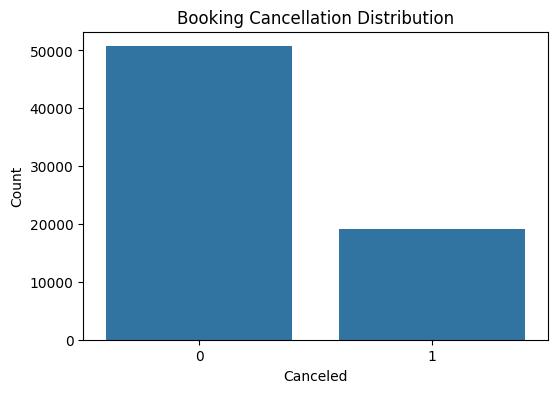

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x=train_df[target])

plt.title("Booking Cancellation Distribution")
plt.xlabel("Canceled")
plt.ylabel("Count")

plt.show()

**Dividing columns to numerical and categorial**

In [ ]:
num_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

cat_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:", len(num_cols))
print("Categorical Features:", len(cat_cols))

Numerical Features: 20
Categorical Features: 12


**visualising  linear correlation between numerical features and target**

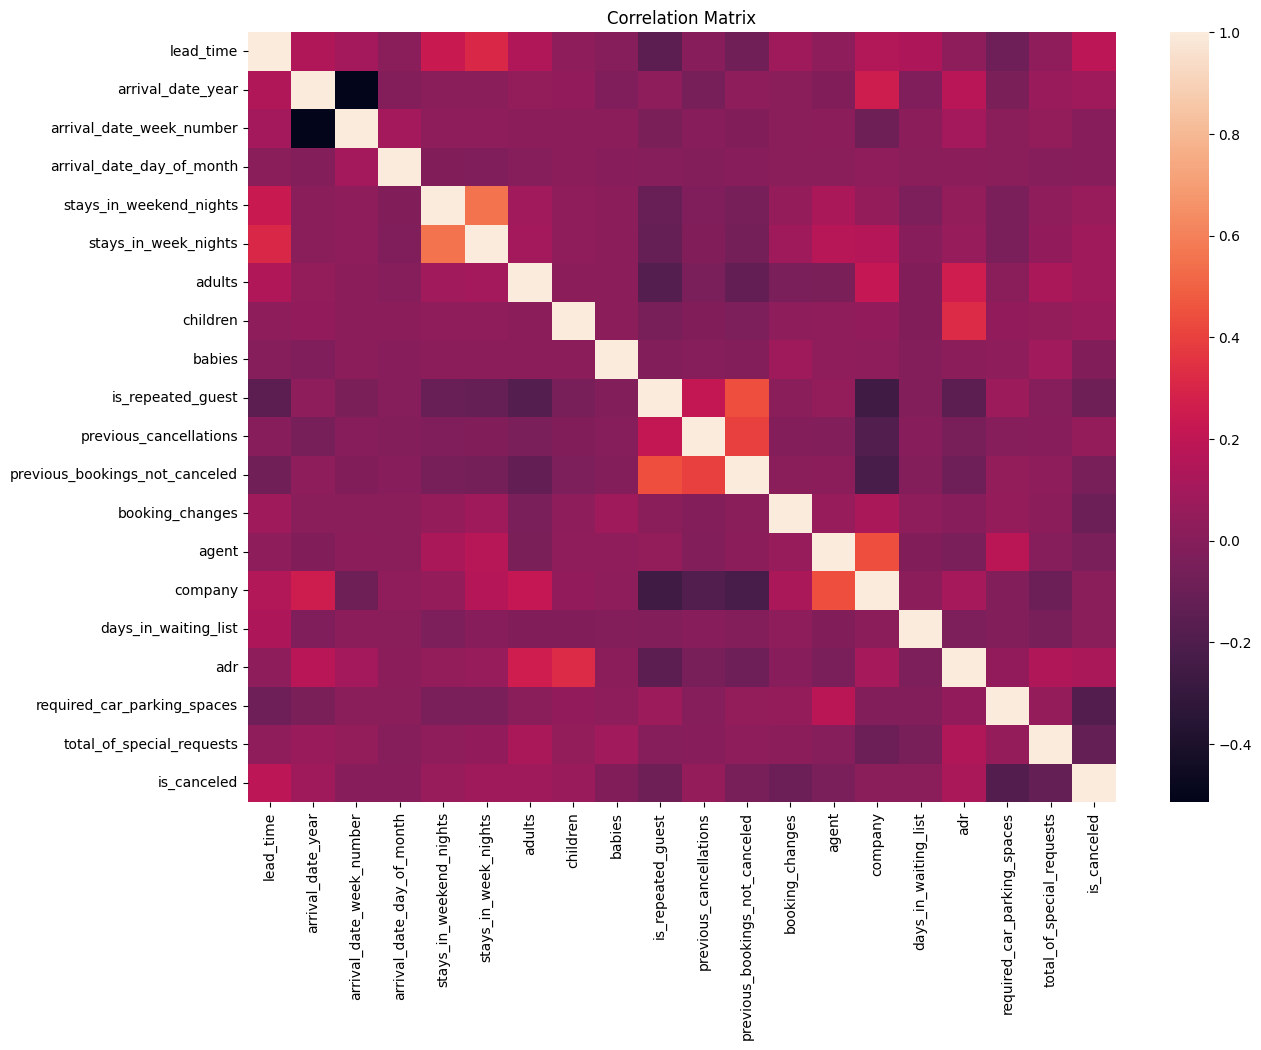

In [ ]:
plt.figure(figsize=(14,10))

corr = train_df[num_cols].corr()

sns.heatmap(corr)

plt.title("Correlation Matrix")

plt.show()

**Mutual information for non linear relationships between features and target**

In [ ]:


temp_df = train_df.copy()


y = temp_df["is_canceled"]


X = temp_df.drop(columns=["is_canceled"])



num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns

# ----------------------------
# Impute numeric
# ----------------------------

num_imputer = SimpleImputer(strategy="median")
X[num_cols] = pd.DataFrame(
    num_imputer.fit_transform(X[num_cols]),
    columns=num_cols,
    index=X.index
)

# ----------------------------
# Impute categorical
# ----------------------------

cat_imputer = SimpleImputer(strategy="most_frequent")
X[cat_cols] = pd.DataFrame(
    cat_imputer.fit_transform(X[cat_cols]),
    columns=cat_cols,
    index=X.index
)

# ----------------------------
# Encode categorical
# ----------------------------

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# ----------------------------
# Verify no NaNs remain
# ----------------------------

print("Remaining NaNs:", X.isnull().sum().sum())

# ----------------------------
# Mutual Information
# ----------------------------

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)


mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information": mi_scores
})

mi_df = mi_df.sort_values(
    by="Mutual_Information",
    ascending=False
)

print(mi_df)

Remaining NaNs: 0
                           Feature  Mutual_Information
29              reservation_status            0.603234
30         reservation_status_date            0.044971
22                           agent            0.044903
26                             adr            0.038898
1                        lead_time            0.037414
13                  market_segment            0.030521
27     required_car_parking_spaces            0.028376
14            distribution_channel            0.020288
12                         country            0.019412
25                   customer_type            0.015578
23                         company            0.015452
21                    deposit_type            0.012917
28       total_of_special_requests            0.011321
8                           adults            0.010767
16          previous_cancellations            0.009793
20                 booking_changes            0.009536
0                            hotel            0

**Cancellation rate vs lead time visualisation**

/tmp/ipykernel_107285/2080378306.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_rate = train_df.groupby('lead_time_bins')['is_canceled'].mean()


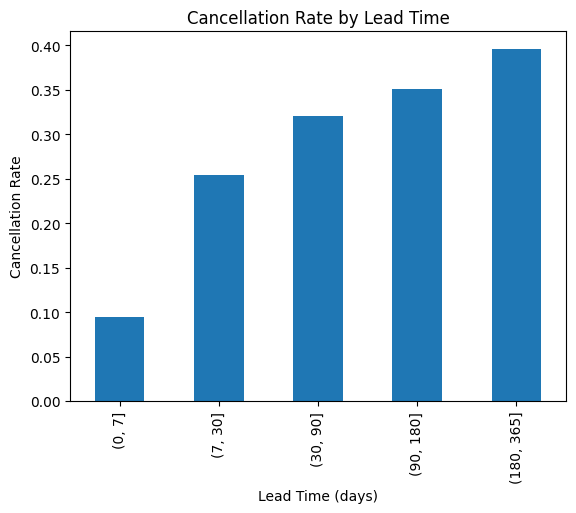

In [ ]:


train_df['lead_time_bins'] = pd.cut(train_df['lead_time'], bins=[0,7,30,90,180,365])

# Calculate cancellation rate
cancel_rate = train_df.groupby('lead_time_bins')['is_canceled'].mean()


cancel_rate.plot(kind='bar')

plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Cancellation Rate')

plt.show()


**Deposit Type vs cancellation rate**

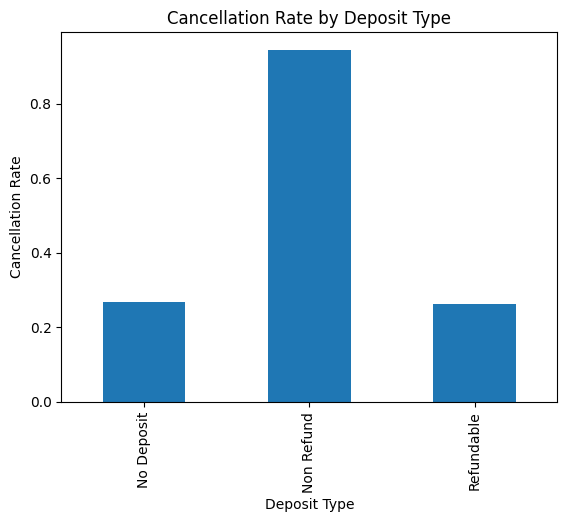

In [ ]:


cancel_rate = train_df.groupby('deposit_type')['is_canceled'].mean()

cancel_rate.plot(kind='bar')

plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate')

plt.show()

## DATA CLEANING


In [ ]:
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 87396 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87392 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            8739

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87392.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,75203.000000,5259.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138640,0.010824,0.039075,0.030413,0.183990,0.271603,94.138306,183.081384,0.749565,106.337246,0.084226,0.698567
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455881,0.113597,0.193775,0.369145,1.731894,0.727245,113.188172,130.557608,10.015731,55.013953,0.281533,0.831946
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,47.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,169.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,263.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
def clean_data(X):
    X = X.copy()

    # -------------------------
    # String cleaning
    # -------------------------
    X['meal'] = X['meal'].str.strip()
    X['country'] = X['country'].str.upper()
    X['market_segment'] = X['market_segment'].str.strip()

    # -------------------------
    # Missing values
    # -------------------------
    X['children'] = X['children'].fillna(0)
    X['country'] = X['country'].fillna('Unknown')
    X['agent'] = X['agent'].fillna(0)

    # -------------------------
    # Drop columns
    # -------------------------
    if 'company' in X.columns:
        X = X.drop('company', axis=1)
    if 'reservation_status' in X.columns:
        X = X.drop('reservation_status', axis=1)

    # -------------------------
    # Remove invalid rows
    # -------------------------
    X = X[~((X['adults'] == 0) & (X['children'] == 0) & (X['babies'] == 0))]

    # -------------------------
    # Handle outliers
    # -------------------------
    X['adr'] = X['adr'].clip(0, 5000)

    # -------------------------
    # Type fixing + Date handling
    # -------------------------
    X['children'] = X['children'].astype(int)

    if 'reservation_status_date' in X.columns:
        X['reservation_status_date'] = pd.to_datetime(
            X['reservation_status_date'],
            errors='coerce'
        )

        X['year'] = X['reservation_status_date'].dt.year
        X['month'] = X['reservation_status_date'].dt.month
        X['day'] = X['reservation_status_date'].dt.day

        X = X.drop('reservation_status_date', axis=1)

        X[['year','month','day']] = X[['year','month','day']].fillna(0)

    # -------------------------
    # Feature Engineering
    # -------------------------
    X['total_people'] = X['adults'] + X['children'] + X['babies']
    X['total_nights'] = X['stays_in_weekend_nights'] + X['stays_in_week_nights']

    return X

In [ ]:
X_train = clean_data(X_train)
y_train = y_train.loc[X_train.index]

In [ ]:
X_test = clean_data(X_test)
y_test = y_test.loc[X_test.index]

## Dimensionality Reduction

In [ ]:

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns
print(f"Numerical columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")


Numerical columns: 20
Categorical columns: 10


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])  #sparse_output=False to get dense array

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

In [ ]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

In [ ]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
X_train_v = vt.fit_transform(X_train_prep)
X_test_v = vt.transform(X_test_prep)

print(f"X_train_v shape: {X_train_v.shape}")
print(f"X_train_v type: {type(X_train_v)}")
print(f"X_train_v dtype: {X_train_v.dtype}\n")

# 7. Get support mask
support_mask = vt.get_support()
print(f"Support mask length: {len(support_mask)}")
print(f"Number of True in support: {sum(support_mask)}")
print(f"Number of False in support: {sum(~support_mask)}\n")

X_train_v shape: (69784, 78)
X_train_v type: <class 'numpy.ndarray'>
X_train_v dtype: float64

Support mask length: 249
Number of True in support: 78
Number of False in support: 171



In [ ]:

vt_features = feature_names[support_mask]

print(f"numbers of features: {len(vt_features)}")

numbers of features: 78


In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

X_train_df = pd.DataFrame(X_train_v, columns=vt_features)
X_test_df = pd.DataFrame(X_test_v, columns=vt_features)

print(f"X_train_df shape: {X_train_df.shape}")
print(f"X_test_df shape: {X_test_df.shape}")

X_train_df shape: (69784, 78)
X_test_df shape: (17446, 78)


In [ ]:

corr_matrix = X_train_df.corr().abs()

# Find highly correlated features
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print(f"Features to drop due to high correlation (>0.9): {len(to_drop)}")

X_train_corr = X_train_df.drop(columns=to_drop)
X_test_corr = X_test_df.drop(columns=to_drop)

print(f"After correlation filter: {X_train_corr.shape[1]} features")

Features to drop due to high correlation (>0.9): 4
After correlation filter: 74 features


In [ ]:
# Mutual Information filtering
mi_scores = mutual_info_classif(X_train_corr, y_train, random_state=42)

mi_series = pd.Series(mi_scores, index=X_train_corr.columns)
mi_series = mi_series.sort_values(ascending=False)

print(f"\nTop 10 features by Mutual Information:")
print(mi_series.head(10))

selected = mi_series[mi_series > 0.01].index
print(f"\nFeatures with MI > 0.01: {len(selected)}")

X_train_final = X_train_corr[selected]
X_test_final = X_test_corr[selected]

print(f"After MI filtering: {X_train_final.shape[1]} features")


Top 10 features by Mutual Information:
num__agent                          0.044774
num__adr                            0.038982
num__lead_time                      0.038858
num__required_car_parking_spaces    0.032558
cat__market_segment_Online TA       0.031273
cat__deposit_type_No Deposit        0.018663
cat__distribution_channel_TA/TO     0.018456
cat__customer_type_Transient        0.016999
num__booking_changes                0.011953
cat__meal_BB                        0.011228
dtype: float64

Features with MI > 0.01: 13
After MI filtering: 13 features


In [ ]:
# PCA
if X_train_final.shape[1] > 10:
    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_final)
    X_test_pca = pca.transform(X_test_final)

    print(f"Final dimensions after PCA: {X_train_pca.shape[1]}")
    print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")


    X_train_final = X_train_pca
    X_test_final = X_test_pca
else:
    print("Not enough features for PCA, skipping...")

print(f"\nFinal training data shape: {X_train_final.shape}")
print(f"Final test data shape: {X_test_final.shape}")

Final dimensions after PCA: 9
Variance explained: 95.90%

Final training data shape: (69784, 9)
Final test data shape: (17446, 9)


In [ ]:
"""bundle = {
    "preprocessor": preprocessor,
    "variance_selector": vt,
    "corr_features": X_train_corr.columns,
    "mi_features": selected,
    "pca": pca,
    "model": svm_model
}"""

'bundle = {\n    "preprocessor": preprocessor,\n    "variance_selector": vt,\n    "corr_features": X_train_corr.columns,\n    "mi_features": selected,\n    "pca": pca,\n    "model": svm_model\n}'

## SVM

In [ ]:
param_grid = {
    "C": [0.1, 1],
    "kernel": ["linear"]
}
grid_search = GridSearchCV(
    estimator=SVC(class_weight='balanced'),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_final, y_train)

print("Best Params:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

best_svm = grid_search.best_estimator_

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Params: {'C': 1, 'kernel': 'linear'}
Best Score: 0.7183021465810752


In [ ]:
y_pred_tuned = best_svm.predict(X_test_final)

In [ ]:
print("\n===== Tuned SVM Results =====")

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))


===== Tuned SVM Results =====
Accuracy: 0.7161526997592571

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78     12644
           1       0.49      0.77      0.60      4802

    accuracy                           0.72     17446
   macro avg       0.69      0.73      0.69     17446
weighted avg       0.78      0.72      0.73     17446



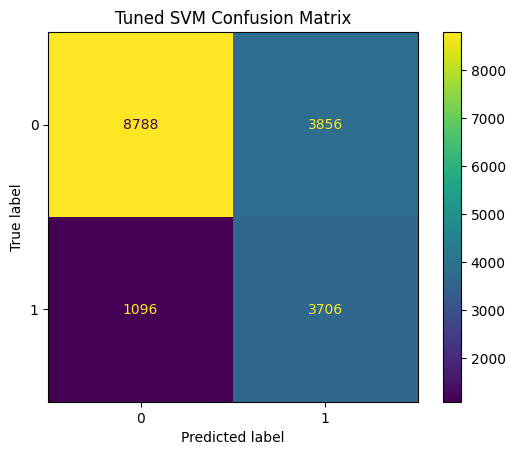

In [ ]:
cm = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Tuned SVM Confusion Matrix")
plt.show()

In [ ]:
y_scores = best_svm.decision_function(X_test_final)

In [ ]:
y_scores

array([ 0.19122026,  0.89072135,  0.97529821, ..., -0.89837122,
       -0.97171032, -0.07870253])

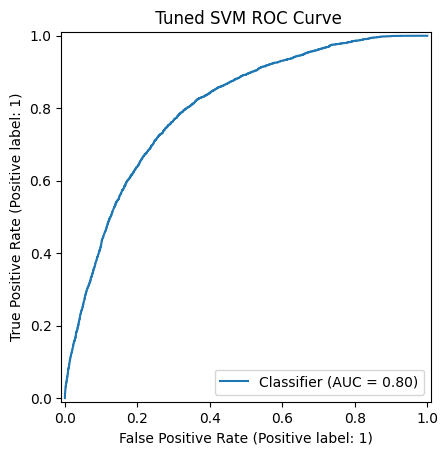

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_scores)
plt.title(" Tuned SVM ROC Curve")
plt.show()

## pipeline

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
import numpy as np
import pandas as pd


class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, vt_threshold=0.01, corr_threshold=0.9, mi_threshold=0.01):
        self.vt_threshold = vt_threshold
        self.corr_threshold = corr_threshold
        self.mi_threshold = mi_threshold

    def fit(self, X, y):
        # convert to array safely
        X = np.array(X)

        # Variance threshold
        self.vt = VarianceThreshold(self.vt_threshold)
        X_vt = self.vt.fit_transform(X)

        # Correlation filter
        corr = np.corrcoef(X_vt, rowvar=False)
        upper = np.triu(np.ones(corr.shape), k=1).astype(bool)

        self.to_drop = set()
        for i in range(corr.shape[0]):
            for j in range(i+1, corr.shape[1]):
                if abs(corr[i, j]) > self.corr_threshold:
                    self.to_drop.add(j)

        keep_mask = np.array([i not in self.to_drop for i in range(X_vt.shape[1])])
        X_corr = X_vt[:, keep_mask]

        # Mutual information
        mi = mutual_info_classif(X_corr, y, random_state=42)

        self.mi_mask = mi > self.mi_threshold
        self.keep_mask = keep_mask

        return self

    def transform(self, X):
        X = np.array(X)

        X_vt = self.vt.transform(X)

        X_corr = X_vt[:, self.keep_mask]

        X_final = X_corr[:, self.mi_mask]

        return X_final

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# -----------------------
# Numeric + categorical columns (from your cleaned data)
# -----------------------
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

# -----------------------
# Preprocessing (IMPORTANT FIX: dense output)
# -----------------------
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

# -----------------------
# Full pipeline
# -----------------------
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("selector", FeatureSelector(
        vt_threshold=0.01,
        corr_threshold=0.9,
        mi_threshold=0.01
    )),

    ("pca", PCA(
        n_components=0.95,
        svd_solver="full"
    )),

    ("svm", SVC(
        C=1,
        kernel="linear",
        class_weight="balanced"
    ))
])

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import pickle

# Train model
full_pipeline.fit(X_train, y_train)

# Predict
y_pred = full_pipeline.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.716210019488708
              precision    recall  f1-score   support

           0       0.89      0.70      0.78     12644
           1       0.49      0.77      0.60      4802

    accuracy                           0.72     17446
   macro avg       0.69      0.73      0.69     17446
weighted avg       0.78      0.72      0.73     17446

